In [1]:
from langchain_community.document_loaders import TextLoader

In [5]:
loader = TextLoader("sample.txt")
documents = loader.load()

In [7]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("test.pdf")
loader.load()

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'test.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser ∗\nGoogle Brain\nlukaszkaise

In [19]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]=os.getenv("LANGSMITH_TRACING")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")


In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.5)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [23]:
response = llm.invoke("What is the capital of France?")
print(response.content)

The capital of France is **Paris**.


In [24]:
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human", "{input}"),
    ]
)
prompt

ChatPromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})])

In [25]:
pipeline = prompt | llm
response = pipeline.invoke(input="What is the capital of France?")
response.content

'The capital of France is **Paris**.'

In [27]:
from langchain_core.output_parsers import StrOutputParser
output_parser = StrOutputParser()
chain = prompt|llm|output_parser
response = chain.invoke(input="What is the capital of France?")

In [28]:
response

'The capital of France is **Paris**.'

In [1]:
from langchain_core.runnables import RunnableParallel
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = ChatOpenAI(model="gpt-4o")
parser = StrOutputParser()

# 1. Define two independent sequences
summary_chain = ChatPromptTemplate.from_template("Summarize this: {text}") | model | parser
keyword_chain = ChatPromptTemplate.from_template("Extract 3 keywords from: {text}") | model | parser

# 2. Combine them into a RunnableParallel
parallel_worker = RunnableParallel(
    summary=summary_chain,
    keywords=keyword_chain
)

# 3. Invoke it
# Both chains receive the exact same input dictionary at the same time
text_input = {"text": "LangGraph is a library for building stateful, multi-actor applications with LLMs."}

result = parallel_worker.invoke(text_input)

# The result is a dictionary containing the outputs of both chains!
print(result["summary"])
print(result["keywords"])


ModuleNotFoundError: No module named 'langchain_openai'

In [ ]:
from langchain_core.runnables import RunnableBranch
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = ChatOpenAI(model="gpt-4o", temperature=0)
parser = StrOutputParser()

# 1. Define the specialized sub-chains
math_chain = ChatPromptTemplate.from_template(
    "You are a strict math professor. Solve this step-by-step: {question}"
) | model | parser

history_chain = ChatPromptTemplate.from_template(
    "You are a historian. Answer this with historical context: {question}"
) | model | parser

general_chain = ChatPromptTemplate.from_template(
    "You are a helpful assistant. Answer: {question}"
) | model | parser

# 2. Define the routing logic using RunnableBranch
branch = RunnableBranch(
    # Format: (Condition Function, Chain to Execute)
    # The lambda function receives the input dictionary passed to the chain
    (lambda x: "math" in x["topic"].lower(), math_chain),
    (lambda x: "history" in x["topic"].lower(), history_chain),
    
    # The default fallback if neither 'math' nor 'history' is in the topic
    general_chain
)

# 3. Execute - Routing to History
print("--- History Request ---")
history_result = branch.invoke({
    "topic": "world history",
    "question": "When did the Roman Empire fall?"
})
print(history_result)

# 4. Execute - Routing to Math
print("\n--- Math Request ---")
math_result = branch.invoke({
    "topic": "advanced math",
    "question": "What is the derivative of x^2?"
})
print(math_result)

In [1]:
from typing import TypedDict


class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str 
    discriminant: float
    result : str

In [8]:
from langchain_protocol import Literal


def show_equation(state: QuadState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {"equation": equation}

def calculate_discriminant(state: QuadState):
    discriminant = state['b'] ** 2 - 4 * state['a'] * state['c']
    return {"discriminant": discriminant}

def real_roots(state: QuadState):
     root1 = (-state['b'] + state['discriminant'] ** 0.5) / (2 * state['a'])
     root2 = (-state['b'] - state['discriminant'] ** 0.5) / (2 * state['a'])
     result = f'The roots are {root1} and {root2}'
     return {"result": result}
def repeated_roots(state: QuadState):
    root = -state['b'] / (2 * state['a'])
    result = f'Only repeated root is {root}'
    return {"result": result}
def no_real_roots(state: QuadState):
    result = "No real roots"
    return {"result": result}
def check_discriminant(state: QuadState)-> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'


In [13]:
from langgraph.graph import END, START, StateGraph


graph=StateGraph(QuadState)
graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
# graph.add_node("check_discriminant",check_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges('calculate_discriminant',check_discriminant)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_real_roots",END)

workflow= graph.compile()

print(workflow)

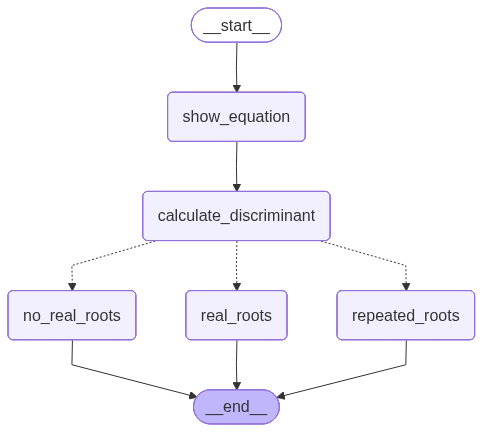

In [15]:
workflow

In [18]:
initial_state = {
    "a": 4,
    "b": 2,
    "c": 4
}
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': 2, 'c': 4, 'equation': '4x^2 + 2x + 4', 'discriminant': -60, 'result': 'No real roots'}
